# Глубинное обучение, ИИ/МОЦП ВШЭ

## Домашнее задание 3. RNN. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в файле `jokes.txt`, который доступен по ссылке https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&st=mff21u6h&dl=0 .

In [4]:
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'


## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [5]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel

In [2]:
train_set = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='bpe')
valid_set = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='bpe')

In [3]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length,)
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1:] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (2 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [4]:
model = LanguageModel(train_set)

In [5]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs,))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ['', 'купил мужик шляпу,', 'сел медведь в машину и', 'подумал штирлиц']:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (1.5 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://medium.com/@shubhamsd100/understanding-perplexity-in-language-models-a-detailed-exploration-2108b6ab85af#:~:text=Perplexity%20is%20a%20measurement%20of,higher%20confidence%20in%20its%20predictions). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

In [6]:
def get_device() -> torch.device:
    device = torch.device('cpu')
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
    return device


DEVICE = get_device()
print(DEVICE)

mps


In [7]:
from torch.utils.data import DataLoader
from train import train

batch_size = 64

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)
val_loader = DataLoader(
    valid_set,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)


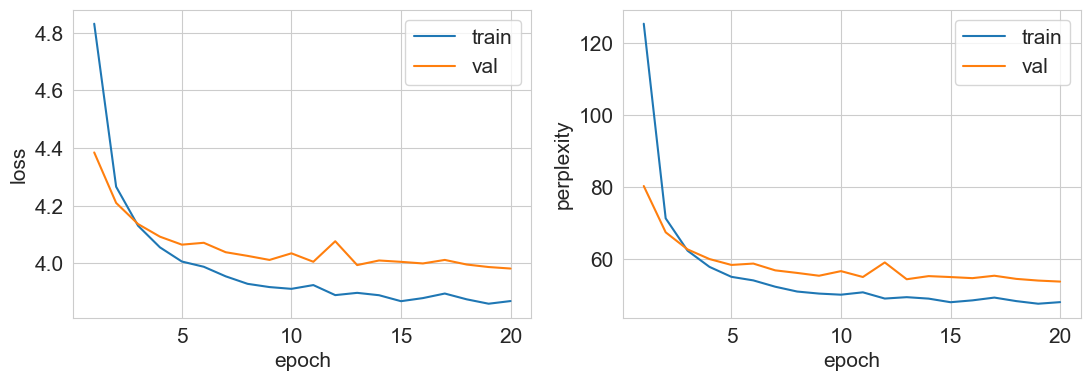

Generation examples:
у учительницы что приходят твой мальчик, написать цифра папы вдвоем селмон, но так что возбуждений ложится?- а прин петренского адвокату в животе? ты, почти только отличная фигрема!са? я за эквисает, что сам сказал не любит тебя...- не дайте, как?- понимаешь, и через 5 лет и пациенц которого деревой уничтожает женщин с работы!- ну хорошо, сюдавой пыталась?- вкусные стороны.
на фоналуш сейчас делает стене студенты.- оно я даже сутио пола погоди что-то каковоразть всем пить ни разучать! я ее поле упал.
мужчина вы гарантированно теще не выдергивает бросает в жард, заходи за двести своих ошибки, состоящее сидят за это нитки.


In [8]:
model = LanguageModel(train_set).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = None  # Можно добавить lr scheduler

# Запуск обучения
train(
    model,
    optimizer,
    scheduler,
    train_loader,
    val_loader,
    num_epochs=20,
    num_examples=3,  # Сколько примеров показывать после каждой эпохи
)

# Сохраняем чекпойнт
torch.save(model.state_dict(), 'rnn_language_model.pt')

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

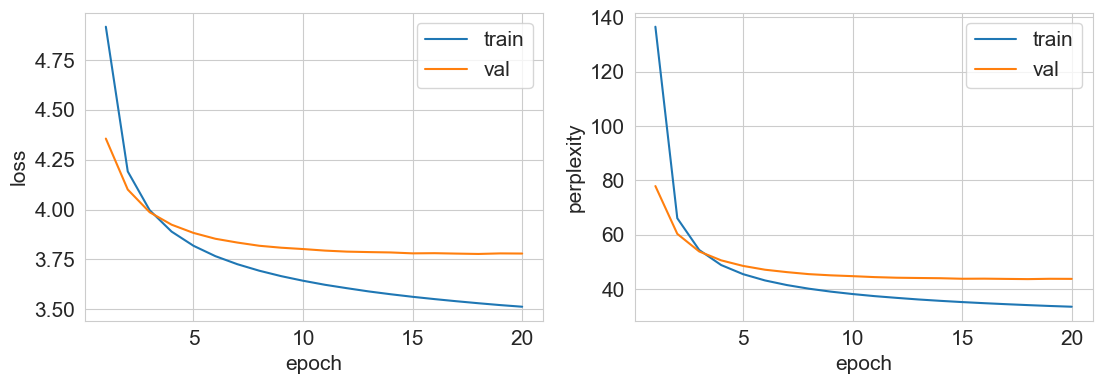

Generation examples:
и же после похороны изжрали энергетики в животе-ашан заманчил выше золотую общественных местах, и две недели берут себя антихапкой.
бывает, мобильники нахрена. с некоторым долбасоком вливые волки отвлечь внимание в 10 минут сюрпризно установит этим пропорционально.
с пеной, помни, таланчаемыми - это рамворке у зубные, а тут правильники и дел...


In [9]:
model_lstm = LanguageModel(train_set, rnn_type=torch.nn.LSTM).to(DEVICE)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
scheduler_lstm = None  # Можно добавить lr scheduler

train(
    model_lstm,
    optimizer_lstm,
    scheduler_lstm,
    train_loader,
    val_loader,
    num_epochs=20,
    num_examples=3,
)

# Сохраняем чекпойнт
torch.save(model_lstm.state_dict(), 'lstm_language_model.pt')

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы. 

In [10]:
import torch
from model import LanguageModel

# Предполагается, что train_set уже создан (и параметры токенизатора совпадают с обучением)
# Загрузим сохраненные модели
model = LanguageModel(train_set)
model.load_state_dict(torch.load('rnn_language_model.pt', map_location='cpu'))
model.eval()  # Перевести в режим инференса

model_lstm = LanguageModel(train_set, rnn_type=torch.nn.LSTM)
model_lstm.load_state_dict(torch.load('lstm_language_model.pt', map_location='cpu'))
model_lstm.eval()

model.to(DEVICE)
model_lstm.to(DEVICE)

LanguageModel(
  (embedding): Embedding(2000, 256, padding_idx=1999)
  (rnn): LSTM(256, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=2000, bias=True)
)

In [11]:
from typing import Any

# Определяем диапазон температур для тестирования
temperatures = [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 1.0]

# Определяем различные префиксы для генерации
prefixes = [
    'Штирлиц зашел к Мюллеру, ',
    'Идет мужик по улице и ',
    'Встречаются два друга, ',
    '',  # Пустой префикс
]


def analyze_temperature_effect(
    model_name: str,
    model: LanguageModel,
    prefixes: list[str],
    temperatures: str = '',
) -> dict[str, Any]:
    # Анализ для RNN модели
    print('Model:', model_name)
    print('=' * 60)

    results = {}
    for prefix in prefixes:
        prefix_name = prefix if prefix else '[Пустой префикс]'
        print(f'\nПрефикс: "{prefix_name}"')
        print('-' * 40)

        results[prefix] = {}
        for temp in temperatures:
            generated = model.inference(prefix, temp)
            results[prefix][temp] = generated
            print(f'T={temp:3.1f}: {generated}')

    return results

In [12]:
rnn_results = analyze_temperature_effect(
    'RNN',
    model, 
    prefixes, 
    temperatures,
)

Model: RNN

Префикс: "Штирлиц зашел к Мюллеру, "
----------------------------------------
T=0.1: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда я задумчиво- ах, а что вы делаете?- да, но я не могу.
T=0.2: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда я не могу понять, что у него есть?- нет, я не могу.
T=0.3: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда вы не знаете, что это не было.
T=0.5: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда я не рассчитавшегося в матери, она вышел из клетки.
T=0.7: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, ты бы их пошла в магазин.
T=0.8: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда злее всего из того, как пздец, физхаки и не нуждается посовока в синах не было?
T=0.9: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, кричит, но и восклик тут же редко.
T=1.0: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, а сегодня вкусные?- давно непьешь, один завод он перестанет работать. нас! чему считать, что о

In [13]:
lstm_results = analyze_temperature_effect(
    'LSTM',
    model, 
    prefixes, 
    temperatures,
)

Model: LSTM

Префикс: "Штирлиц зашел к Мюллеру, "
----------------------------------------
T=0.1: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда я буду жить с ним, а не вредно.
T=0.2: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда я могу себе позвонить, что я не могу.
T=0.3: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда я не знаю, что это не только в порядке.
T=0.5: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, что ты в нем не пережил, что у меня есть есть, но еще не используют.
T=0.7: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, что у нее есть что-то налево.
T=0.8: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, например, приходилось.
T=0.9: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, я все у одиночествато из секретности.
T=1.0: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, поднутой назад я думает!

Префикс: "Идет мужик по улице и "
----------------------------------------
T=0.1: Идет мужик по улице и идет мужик по улице искал.
T=0.2: И

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

In [14]:
# BPE с vocab_size=8000 (вместо 2000)
train_set_bpe8k = TextDataset(
    data_file='jokes.txt',
    train=True,
    sp_model_prefix='bpe_8k',
    vocab_size=8000,
    model_type='bpe',
)

valid_set_bpe8k = TextDataset(
    data_file='jokes.txt',
    train=False,
    sp_model_prefix='bpe_8k',
    vocab_size=8000,
    model_type='bpe',
)

# Unigram с vocab_size=4000
train_set_unigram = TextDataset(
    data_file='jokes.txt',
    train=True,
    sp_model_prefix='unigram',
    vocab_size=4000,
    model_type='unigram',
)

valid_set_unigram = TextDataset(
    data_file='jokes.txt',
    train=False,
    sp_model_prefix='unigram',
    vocab_size=4000,
    model_type='unigram',
)

# Сравнение размеров словарей
print(f'BPE-2K (базовый):  {train_set.vocab_size}')
print(f'BPE-8K:            {train_set_bpe8k.vocab_size}')
print(f'Unigram-4K:        {train_set_unigram.vocab_size}')

BPE-2K (базовый):  2000
BPE-8K:            8000
Unigram-4K:        4000


In [15]:
# Тест на примере
test_text = "Штирлиц зашел к Мюллеру, а тот сидел и думал о чем-то важном."

print(f"Исходный текст: '{test_text}'\n")

# BPE-2K
tokens_bpe2k = train_set.text2ids(test_text)
print(f"BPE-2K ({len(tokens_bpe2k)} токенов): {tokens_bpe2k}")
print(f"Декодировано: '{train_set.ids2text(tokens_bpe2k)}'")
print()

# BPE-8K
tokens_bpe8k = train_set_bpe8k.text2ids(test_text)
print(f"BPE-8K ({len(tokens_bpe8k)} токенов): {tokens_bpe8k}")
print(f"Декодировано: '{train_set_bpe8k.ids2text(tokens_bpe8k)}'")
print()

# Unigram
tokens_unigram = train_set_unigram.text2ids(test_text)
print(f"Unigram-4K ({len(tokens_unigram)} токенов): {tokens_unigram}")
print(f"Декодировано: '{train_set_unigram.ids2text(tokens_unigram)}'")

print(f"\n📈 ЭФФЕКТИВНОСТЬ ТОКЕНИЗАЦИИ:")
print(f"BPE-2K:     {len(tokens_bpe2k)} токенов")
print(
    f"BPE-8K:     {len(tokens_bpe8k)} токенов (сжатие: {len(tokens_bpe2k)/len(tokens_bpe8k):.2f}x)"
)
print(
    f"Unigram-4K: {len(tokens_unigram)} токенов (сжатие: {len(tokens_bpe2k)/len(tokens_unigram):.2f}x)"
)

Исходный текст: 'Штирлиц зашел к Мюллеру, а тот сидел и думал о чем-то важном.'

BPE-2K (23 токенов): [660, 48, 393, 8, 1839, 1181, 1972, 1977, 40, 742, 221, 603, 17, 437, 1968, 13, 303, 1983, 7, 123, 1985, 425, 1975]
Декодировано: 'штирлиц зашел к мюллеру, а тот сидел и думал о чем-то важном.'

BPE-8K (18 токенов): [660, 4334, 8, 2150, 7972, 7977, 40, 742, 4522, 17, 2185, 13, 303, 7983, 7, 4129, 425, 7975]
Декодировано: 'штирлиц зашел к мюллеру, а тот сидел и думал о чем-то важном.'

Unigram-4K (19 токенов): [323, 25, 828, 39, 1188, 24, 3, 15, 410, 2068, 10, 896, 59, 135, 9, 51, 2493, 22, 4]
Декодировано: 'штирлиц зашел к мюллеру, а тот сидел и думал о чем-то важном.'

📈 ЭФФЕКТИВНОСТЬ ТОКЕНИЗАЦИИ:
BPE-2K:     23 токенов
BPE-8K:     18 токенов (сжатие: 1.28x)
Unigram-4K: 19 токенов (сжатие: 1.21x)


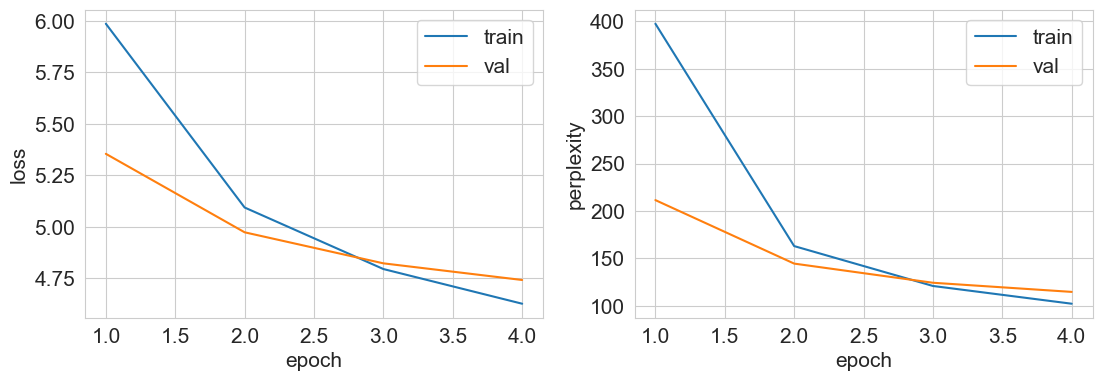

Generation examples:
на  ⁇  марта, прежде чем принесимость отдохнуть. значит, муж хочет почти, жили его, его карманы и?
- что вы думаешь что ваши девушки, жижки?- овчи интересыла! вот черт, кате-то женщина схватил я был увольнения, путин точно расион ответил и им доверчалимся и счастливее.


Training 5/15:   0%|          | 0/1792 [00:00<?, ?it/s]

In [ ]:
# Используем LSTM как лучшую модель из предыдущего задания
from torch.utils.data import DataLoader
from train import train

batch_size = 64

# Обучение модели с BPE-8K
print("\nОбучение LSTM модели с BPE-8K токенизатором...")
train_loader_bpe8k = DataLoader(
    train_set_bpe8k, batch_size=batch_size, shuffle=True, drop_last=True
)
val_loader_bpe8k = DataLoader(
    valid_set_bpe8k, batch_size=batch_size, shuffle=False, drop_last=False
)

model_lstm_bpe8k = LanguageModel(train_set_bpe8k, rnn_type=torch.nn.LSTM).to(DEVICE)
optimizer_bpe8k = torch.optim.Adam(model_lstm_bpe8k.parameters(), lr=1e-3)

train(
    model_lstm_bpe8k,
    optimizer_bpe8k,
    None,
    train_loader_bpe8k,
    val_loader_bpe8k,
    num_epochs=15,
    num_examples=2,
)

torch.save(model_lstm_bpe8k.state_dict(), "lstm_bpe8k_model.pt")
print("=== Модель BPE-8K сохранена ===")

In [ ]:
# Обучение модели с Unigram
print("\nОбучение LSTM модели с Unigram токенизатором...")
train_loader_unigram = DataLoader(
    train_set_unigram, batch_size=batch_size, shuffle=True, drop_last=True
)
val_loader_unigram = DataLoader(
    valid_set_unigram, batch_size=batch_size, shuffle=False, drop_last=False
)

model_lstm_unigram = LanguageModel(train_set_unigram, rnn_type=torch.nn.LSTM).to(DEVICE)
optimizer_unigram = torch.optim.Adam(model_lstm_unigram.parameters(), lr=1e-3)

train(
    model_lstm_unigram,
    optimizer_unigram,
    None,
    train_loader_unigram,
    val_loader_unigram,
    num_epochs=15,
    num_examples=2,
)

torch.save(model_lstm_unigram.state_dict(), "lstm_unigram_model.pt")
print("=== Модель Unigram сохранена ===")

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [ ]:

import re

import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm


def clean_text(text):
    """Очистка текста для LSA анализа"""
    # Удаляем специальные символы и приводим к нижнему регистру
    text = re.sub(r"[^а-яё\s]", " ", text.lower())
    # Удаляем лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()
    return text


def generate_texts_for_lsa(model, dataset, num_texts, max_length=100):
    """Генерация текстов для LSA анализа"""
    model.eval()
    generated_texts = []

    prefixes = [
        "",
        "идет мужик",
        "встречаются два",
        "штирлиц",
        "приходит",
        "сидит",
        "звонит",
        "покупает",
    ]

    texts_per_prefix = num_texts // len(prefixes) + 1

    with torch.no_grad():
        for prefix in prefixes:
            for _ in range(texts_per_prefix):
                if len(generated_texts) >= num_texts:
                    break

                try:
                    # Генерируем с разными температурами для разнообразия
                    temp = np.random.uniform(0.6, 0.9)
                    text = model.inference(prefix, temp=temp)

                    # Очищаем текст
                    cleaned_text = clean_text(text)

                    # Проверяем минимальную длину
                    if len(cleaned_text.split()) >= 5:
                        generated_texts.append(cleaned_text)
                except Exception as e:
                    print(f"Ошибка при генерации: {e}")
                    continue

            if len(generated_texts) >= num_texts:
                break

    return generated_texts[:num_texts]


def prepare_validation_texts(dataset, num_texts=None):
    """Подготовка валидационных текстов"""
    validation_texts = []

    # Ограничиваем число текстов
    max_texts = len(dataset) if num_texts is None else min(num_texts, len(dataset))

    for i in range(max_texts):
        indices, length = dataset[i]

        # Убираем BOS и EOS токены
        text_indices = indices[1 : length - 1]
        # Декодируем текст
        text = dataset.sp_model.decode(text_indices.tolist())

        # Очищаем текст
        cleaned_text = clean_text(text)

        if len(cleaned_text.split()) >= 5:
            validation_texts.append(cleaned_text)

    return validation_texts


def compute_lsa_metric(generated_texts, validation_texts, n_components=100):
    # Объединяем все тексты
    all_texts = validation_texts + generated_texts

    # Создаем TF-IDF матрицу
    vectorizer = TfidfVectorizer(
        max_features=5000,
        min_df=2,
        max_df=0.8,
        ngram_range=(1, 2),
        stop_words=None,  # Для русского языка можем добавить стоп-слова ?
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(all_texts)
    except ValueError as e:
        print(f"Ошибка при создании TF-IDF матрицы: {e}")
        return 0.0

    # Применяем SVD для понижения размерности
    n_components = min(n_components, tfidf_matrix.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=42)

    try:
        lsa_matrix = svd.fit_transform(tfidf_matrix)
    except ValueError as e:
        print(f"Ошибка при SVD: {e}")
        return 0.0

    # Разделяем на валидационные и сгенерированные векторы
    n_val = len(validation_texts)
    val_vectors = lsa_matrix[:n_val]
    gen_vectors = lsa_matrix[n_val:]

    if len(gen_vectors) == 0:
        return 0.0

    # Вычисляем cosine similarity
    similarities = cosine_similarity(gen_vectors, val_vectors)

    # Для каждого сгенерированного текста находим максимальную схожесть
    max_similarities = np.max(similarities, axis=1)

    # Возвращаем среднюю максимальную схожесть
    return np.mean(max_similarities)

In [ ]:
print("Создаем датасеты ...")

# BPE-2K (оригинальный)
train_set_bpe2k = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set_bpe2k = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")

# BPE-8K
train_set_bpe8k = TextDataset(
    data_file="jokes.txt", train=True, sp_model_prefix="bpe_8k", vocab_size=8000
)
valid_set_bpe8k = TextDataset(
    data_file="jokes.txt", train=False, sp_model_prefix="bpe_8k", vocab_size=8000
)

# Unigram-4K
train_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=True,
    sp_model_prefix="unigram",
    vocab_size=4000,
    model_type="unigram",
)
valid_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=False,
    sp_model_prefix="unigram",
    vocab_size=4000,
    model_type="unigram",
)


print("Загружаем модели ...")

# LSTM с BPE-2K
model_bpe2k = LanguageModel(train_set_bpe2k, rnn_type=torch.nn.LSTM).to(device)
model_bpe2k.load_state_dict(torch.load("lstm_language_model.pt", map_location=device))
model_bpe2k.eval()

# LSTM с BPE-8K
model_bpe8k = LanguageModel(train_set_bpe8k, rnn_type=torch.nn.LSTM).to(device)
model_bpe8k.load_state_dict(torch.load("lstm_bpe8k_model.pt", map_location=device))
model_bpe8k.eval()

# LSTM с Unigram-4K
model_unigram = LanguageModel(train_set_unigram, rnn_type=torch.nn.LSTM).to(device)
model_unigram.load_state_dict(torch.load("lstm_unigram_model.pt", map_location=device))
model_unigram.eval()

In [ ]:
# Размер выборки равен валидационной выборке
num_texts = len(valid_set_bpe2k)
print(f"Размер выборки: {num_texts}")

# Генерируем тексты
print("Генерация текстов BPE-2K модели...")
generated_bpe2k = generate_texts_for_lsa(model_bpe2k, train_set_bpe2k, num_texts)
print(f"Сгенерировано: {len(generated_bpe2k)} текстов")

print("Генерация текстов BPE-8K модели...")
generated_bpe8k = generate_texts_for_lsa(model_bpe8k, train_set_bpe8k, num_texts)
print(f"Сгенерировано: {len(generated_bpe8k)} текстов")

print("Генерация текстов Unigram-4K модели...")
generated_unigram = generate_texts_for_lsa(model_unigram, train_set_unigram, num_texts)
print(f"Сгенерировано: {len(generated_unigram)} текстов")

# Подготавливаем валидационные тексты (используем BPE-2K как базовый)
print("Подготовка валидационных текстов...")
validation_texts = prepare_validation_texts(valid_set_bpe2k, num_texts)
print(f"Валидационных текстов: {len(validation_texts)}")

print("\nПримеры сгенерированных текстов:")
print("\nBPE-2K:")
for i, text in enumerate(generated_bpe2k[:3]):
    print(f"{i+1}. {text}")

print("\nBPE-8K:")
for i, text in enumerate(generated_bpe8k[:3]):
    print(f"{i+1}. {text}")

print("\nUnigram-4K:")
for i, text in enumerate(generated_unigram[:3]):
    print(f"{i+1}. {text}")

In [ ]:
# сохранение / восстановление сгенерированных текстов
import joblib

# Создание структуры данных для сохранения
results = {
    "generated_bpe2k": generated_bpe2k,
    "generated_bpe8k": generated_bpe8k,
    "generated_unigram": generated_unigram,
}

# Сохранение
joblib.dump(results, "generated_texts.joblib")

# # Восстановление
# loaded_results = joblib.load('generated_texts.joblib')
# generated_bpe2k_restored = loaded_results['generated_bpe2k']
# generated_bpe8k_restored = loaded_results['generated_bpe8k']
# generated_unigram_restored = loaded_results['generated_unigram']

In [ ]:
# Используем подвыборку для ускорения вычислений
sample_size = min(1000, len(validation_texts))
val_sample = validation_texts[:sample_size]
gen_sample_size = min(500, len(generated_bpe2k))

print(
    f"Используем {len(val_sample)} валидационных и {gen_sample_size} сгенерированных текстов"
)

# LSA метрика для BPE-2K
print("\nВычисление LSA для BPE-2K...")
lsa_bpe2k = compute_lsa_metric(
    generated_bpe2k[:gen_sample_size], val_sample, n_components=50
)

# LSA метрика для BPE-8K
print("Вычисление LSA для BPE-8K...")
lsa_bpe8k = compute_lsa_metric(
    generated_bpe8k[:gen_sample_size], val_sample, n_components=50
)

# LSA метрика для Unigram-4K
print("Вычисление LSA для Unigram-4K...")
lsa_unigram = compute_lsa_metric(
    generated_unigram[:gen_sample_size], val_sample, n_components=50
)

print(f"LSTM + BPE-2K:     LSA Score = {lsa_bpe2k:.4f}")
print(f"LSTM + BPE-8K:     LSA Score = {lsa_bpe8k:.4f}")
print(f"LSTM + Unigram-4K: LSA Score = {lsa_unigram:.4f}")

## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
## Задание 7. Visualization (2/3 балла)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE


def get_lsa_vectors_for_visualization(
    generated_texts, validation_texts, n_components=50
):
    """Получение LSA векторов для визуализации"""
    # Объединяем все тексты
    all_texts = validation_texts + generated_texts

    # Создаем TF-IDF матрицу
    vectorizer = TfidfVectorizer(
        max_features=5000, min_df=2, max_df=0.8, ngram_range=(1, 2), stop_words=None
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(all_texts)
    except ValueError as e:
        print(f"Ошибка при создании TF-IDF матрицы: {e}")
        return None, None

    # Применяем SVD для понижения размерности
    n_components = min(n_components, tfidf_matrix.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=42)

    try:
        lsa_matrix = svd.fit_transform(tfidf_matrix)
    except ValueError as e:
        print(f"Ошибка при SVD: {e}")
        return None, None

    # Разделяем на валидационные и сгенерированные векторы
    n_val = len(validation_texts)
    val_vectors = lsa_matrix[:n_val]
    gen_vectors = lsa_matrix[n_val:]

    return val_vectors, gen_vectors


def create_tsne_visualization(models_data, sample_size=300):
    """Создание t-SNE визуализации для всех моделей"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        "t-SNE Визуализация LSA векторов для разных токенизаторов",
        fontsize=16,
        fontweight="bold",
    )

    for idx, (model_name, data) in enumerate(models_data.items()):
        val_texts = data["validation_texts"][:sample_size]
        gen_texts = data["generated_texts"][:sample_size]
        lsa_score = data["lsa_score"]

        print(f"Обработка {model_name}...")

        # Получаем LSA векторы
        val_vectors, gen_vectors = get_lsa_vectors_for_visualization(
            gen_texts, val_texts, n_components=50
        )

        if val_vectors is None or gen_vectors is None:
            print(f"Ошибка при обработке {model_name}")
            continue

        # Объединяем векторы для t-SNE
        all_vectors = np.vstack([val_vectors, gen_vectors])

        # Применяем t-SNE
        print(f"Применение t-SNE для {model_name}...")
        tsne = TSNE(
            n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=0
        )

        tsne_results = tsne.fit_transform(all_vectors)

        # Разделяем результаты обратно
        n_val = len(val_vectors)
        val_tsne = tsne_results[:n_val]
        gen_tsne = tsne_results[n_val:]

        # Создаем scatter plot
        ax = axes[idx]

        # Валидационные тексты (синий)
        scatter_val = ax.scatter(
            val_tsne[:, 0],
            val_tsne[:, 1],
            c="blue",
            alpha=0.6,
            s=20,
            label="Валидационные тексты",
        )

        # Сгенерированные тексты (красный)
        scatter_gen = ax.scatter(
            gen_tsne[:, 0],
            gen_tsne[:, 1],
            c="red",
            alpha=0.6,
            s=20,
            label="Сгенерированные тексты",
        )

        # Оформление
        ax.set_title(
            f"{model_name}\nLSA Score: {lsa_score:.4f}", fontsize=12, fontweight="bold"
        )
        ax.set_xlabel("t-SNE компонента 1")
        ax.set_ylabel("t-SNE компонента 2")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Подготавливаем данные для визуализации
print("Подготовка данных для t-SNE визуализации...")

models_data = {
    "BPE-2K": {
        "validation_texts": validation_texts,
        "generated_texts": generated_bpe2k,
        "lsa_score": lsa_bpe2k,
    },
    "BPE-8K": {
        "validation_texts": validation_texts,
        "generated_texts": generated_bpe8k,
        "lsa_score": lsa_bpe8k,
    },
    "Unigram-4K": {
        "validation_texts": validation_texts,
        "generated_texts": generated_unigram,
        "lsa_score": lsa_unigram,
    },
}

# Создаем визуализацию
create_tsne_visualization(models_data, sample_size=1500)

## Задание 8. ruGPT perplexity (2 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [ ]:
import numpy as np
import torch
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

print("Загрузка ruGPT3-small модели и токенизатора...")
# tokenizer_gpt = AutoTokenizer.from_pretrained("sberbank-ai/rugpt3small_based_on_gpt2")
# model_gpt = AutoModelForCausalLM.from_pretrained("sberbank-ai/rugpt3small_based_on_gpt2")

tokenizer_gpt = AutoTokenizer.from_pretrained("ai-forever/rugpt3small_based_on_gpt2")
model_gpt = AutoModelForCausalLM.from_pretrained("ai-forever/rugpt3small_based_on_gpt2")

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
model_gpt.to(device)
model_gpt.eval()
print("Модель ruGPT3-small загружена.")


def calculate_perplexity(texts, model, tokenizer):
    total_nll = 0.0
    total_tokens = 0

    for text in tqdm(texts, desc="Вычисление perplexity"):
        # Токенизация текста
        input_ids = tokenizer.encode(text, return_tensors="pt").to(device)

        # Пропускаем слишком короткие тексты, которые могут вызвать проблемы
        if input_ids.shape[1] < 2:
            continue

        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
            loss = outputs.loss

        # NLL (Negative Log-Likelihood) - это и есть loss
        total_nll += loss.item() * input_ids.shape[1]
        total_tokens += input_ids.shape[1]

    if total_tokens == 0:
        return float("inf")  # Возвращаем бесконечность, если нет токенов

    perplexity = torch.exp(torch.tensor(total_nll / total_tokens))
    return perplexity.item()


# Вычисление perplexity для каждой сгенерированной выборки
print("\nВычисление perplexity для BPE-2K...")
ppl_bpe2k = calculate_perplexity(generated_bpe2k, model_gpt, tokenizer_gpt)

print("Вычисление perplexity для BPE-8K...")
ppl_bpe8k = calculate_perplexity(generated_bpe8k, model_gpt, tokenizer_gpt)

print("Вычисление perplexity для Unigram-4K...")
ppl_unigram = calculate_perplexity(generated_unigram, model_gpt, tokenizer_gpt)

# Чем ниже perplexity, тем лучше модель.
print(f"\nPerplexity (ruGPT3-small):")
print(f"LSTM + BPE-2K:     {ppl_bpe2k:.4f}")
print(f"LSTM + BPE-8K:     {ppl_bpe8k:.4f}")
print(f"LSTM + Unigram-4K: {ppl_unigram:.4f}")

## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.